In [30]:
import numpy as np
import pandas as pd

<h1 style="color:#000000;">Data uploading</h1>

In [31]:
df=pd.read_csv("Student_Performance.csv")
df.head(5)

,student_id,age,gender,school_type,parent_education,study_hours,attendance_percentage,internet_access,travel_time,extra_activities,study_method,math_score,science_score,english_score,overall_score,final_grade
0,1,14,male,public,post graduate,3.1,84.3,yes,<15 min,yes,notes,42.7,55.4,57.0,53.1,e
1,2,18,female,public,graduate,3.7,87.8,yes,>60 min,no,textbook,57.6,68.8,64.8,61.3,d
2,3,17,female,private,post graduate,7.9,65.5,no,<15 min,no,notes,84.8,95.0,79.2,89.6,b
3,4,16,other,public,high school,1.1,58.1,no,15-30 min,no,notes,44.4,27.5,54.7,41.6,e
4,5,16,female,public,high school,1.3,61.0,yes,30-60 min,yes,group study,8.9,32.7,30.0,25.4,f


In [32]:
print(df.columns)

Index(['student_id', 'age', 'gender', 'school_type', 'parent_education',
       'study_hours', 'attendance_percentage', 'internet_access',
       'travel_time', 'extra_activities', 'study_method', 'math_score',
       'science_score', 'english_score', 'overall_score', 'final_grade'],
      dtype='object')


In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             25000 non-null  int64  
 1   age                    25000 non-null  int64  
 2   gender                 25000 non-null  object 
 3   school_type            25000 non-null  object 
 4   parent_education       25000 non-null  object 
 5   study_hours            25000 non-null  float64
 6   attendance_percentage  25000 non-null  float64
 7   internet_access        25000 non-null  object 
 8   travel_time            25000 non-null  object 
 9   extra_activities       25000 non-null  object 
 10  study_method           25000 non-null  object 
 11  math_score             25000 non-null  float64
 12  science_score          25000 non-null  float64
 13  english_score          25000 non-null  float64
 14  overall_score          25000 non-null  float64
 15  fi

<h1 style="color:#000000;">Data cleaning</h1>

In [34]:
df.isnull().sum()

student_id               0
age                      0
gender                   0
school_type              0
parent_education         0
study_hours              0
attendance_percentage    0
internet_access          0
travel_time              0
extra_activities         0
study_method             0
math_score               0
science_score            0
english_score            0
overall_score            0
final_grade              0
dtype: int64

In [35]:
print(df.duplicated().sum())

10000


In [36]:
duplicates=[col for col in df.columns if df[col].duplicated().any()]
print(duplicates)

['student_id', 'age', 'gender', 'school_type', 'parent_education', 'study_hours', 'attendance_percentage', 'internet_access', 'travel_time', 'extra_activities', 'study_method', 'math_score', 'science_score', 'english_score', 'overall_score', 'final_grade']


In [37]:
df.apply(lambda col: col.duplicated().sum())

student_id               10000
age                      24994
gender                   24997
school_type              24998
parent_education         24994
study_hours              24924
attendance_percentage    24499
internet_access          24998
travel_time              24996
extra_activities         24998
study_method             24994
math_score               24094
science_score            24093
english_score            24096
overall_score            24192
final_grade              24994
dtype: int64

In [38]:
df = df.drop_duplicates()
print(df.duplicated().sum())

0


In [39]:
df=df.set_index("student_id")
df.head()

,age,gender,school_type,parent_education,study_hours,attendance_percentage,internet_access,travel_time,extra_activities,study_method,math_score,science_score,english_score,overall_score,final_grade
student_id,,,,,,,,,,,,,,,
1,14,male,public,post graduate,3.1,84.3,yes,<15 min,yes,notes,42.7,55.4,57.0,53.1,e
2,18,female,public,graduate,3.7,87.8,yes,>60 min,no,textbook,57.6,68.8,64.8,61.3,d
3,17,female,private,post graduate,7.9,65.5,no,<15 min,no,notes,84.8,95.0,79.2,89.6,b
4,16,other,public,high school,1.1,58.1,no,15-30 min,no,notes,44.4,27.5,54.7,41.6,e
5,16,female,public,high school,1.3,61.0,yes,30-60 min,yes,group study,8.9,32.7,30.0,25.4,f


<h1 style="color:#000000;">Data transformation</h1>

In [41]:
numerical_df = df.select_dtypes(include=['number'])
categorical_df = df.select_dtypes(include=['object', 'category'])

In [42]:
categorical_df.head()

,gender,school_type,parent_education,internet_access,travel_time,extra_activities,study_method,final_grade
student_id,,,,,,,,
1,male,public,post graduate,yes,<15 min,yes,notes,e
2,female,public,graduate,yes,>60 min,no,textbook,d
3,female,private,post graduate,no,<15 min,no,notes,b
4,other,public,high school,no,15-30 min,no,notes,e
5,female,public,high school,yes,30-60 min,yes,group study,f


In [43]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
def encodCategoricalData(cat_df):
    le = LabelEncoder()
    for column in cat_df:
        cat_df[column]=le.fit_transform(cat_df[column])
    return cat_df

In [44]:
categorical_df=encodCategoricalData(categorical_df)

In [45]:
categorical_df.astype(int)

,gender,school_type,parent_education,internet_access,travel_time,extra_activities,study_method,final_grade
student_id,,,,,,,,
1,1,1,5,1,2,1,3,4
2,0,1,1,1,3,0,5,3
3,0,0,5,0,2,0,3,1
4,2,1,2,0,0,0,3,4
5,0,1,2,1,1,1,1,5
...,...,...,...,...,...,...,...,...
14996,1,0,1,1,0,0,1,5
14997,2,0,0,0,2,1,2,2
14998,1,0,4,1,1,0,1,3


In [46]:
df=pd.concat([categorical_df,numerical_df],axis=1)
df.head()

,gender,school_type,parent_education,internet_access,travel_time,extra_activities,study_method,final_grade,age,study_hours,attendance_percentage,math_score,science_score,english_score,overall_score
student_id,,,,,,,,,,,,,,,
1,1,1,5,1,2,1,3,4,14,3.1,84.3,42.7,55.4,57.0,53.1
2,0,1,1,1,3,0,5,3,18,3.7,87.8,57.6,68.8,64.8,61.3
3,0,0,5,0,2,0,3,1,17,7.9,65.5,84.8,95.0,79.2,89.6
4,2,1,2,0,0,0,3,4,16,1.1,58.1,44.4,27.5,54.7,41.6
5,0,1,2,1,1,1,1,5,16,1.3,61.0,8.9,32.7,30.0,25.4


In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15000 entries, 1 to 15000
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   gender                 15000 non-null  int64  
 1   school_type            15000 non-null  int64  
 2   parent_education       15000 non-null  int64  
 3   internet_access        15000 non-null  int64  
 4   travel_time            15000 non-null  int64  
 5   extra_activities       15000 non-null  int64  
 6   study_method           15000 non-null  int64  
 7   final_grade            15000 non-null  int64  
 8   age                    15000 non-null  int64  
 9   study_hours            15000 non-null  float64
 10  attendance_percentage  15000 non-null  float64
 11  math_score             15000 non-null  float64
 12  science_score          15000 non-null  float64
 13  english_score          15000 non-null  float64
 14  overall_score          15000 non-null  float64
dtypes: floa

In [48]:
X=df.drop(["final_grade"],axis=1)
Y=df["final_grade"]

In [52]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import accuracy_score

In [55]:
X_train, X_test, y_train, y_test = train_test_split(
    X, Y,
    test_size=0.3,
    random_state=42,
    stratify=Y
)

In [59]:
knn = KNeighborsClassifier(n_neighbors=10)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)
print(f"Test Accuracy (k=10): {accuracy_score(y_test, y_pred):.2f}")

Test Accuracy (k=5): 0.88


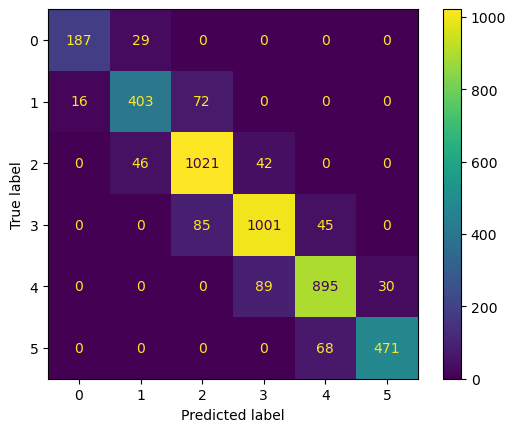

In [60]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot()

In [61]:
train_acc = knn.score(X_train, y_train)
test_acc = knn.score(X_test, y_test)
print(train_acc, test_acc)

0.9166666666666666 0.884


<h1>Import the model for the UI</h1>

In [62]:
import pickle
myData={
"model":knn,
"df":df,
}

In [63]:
filename="dataMining.sav"
pickle.dump(myData,open(filename,"wb"))